In [1]:
!pip install geopandas rasterio shapely fiona pyproj rtree
!pip install rioxarray rasterstats
!pip install matplotlib.pyplot
!pip install seaborn

   ---------------------------------------- 0.0/25.4 MB ? eta -:--:--
   --------- ------------------------------ 5.8/25.4 MB 28.5 MB/s eta 0:00:01
   -------------------- ------------------- 13.1/25.4 MB 31.4 MB/s eta 0:00:01
   ------------------------------ --------- 19.1/25.4 MB 30.6 MB/s eta 0:00:01
   ---------------------------------------  24.9/25.4 MB 29.7 MB/s eta 0:00:01
   ---------------------------------------- 25.4/25.4 MB 27.8 MB/s eta 0:00:00
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 1.7/1.7 MB 21.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/24.5 MB ? eta -:--:--
   ------ --------------------------------- 4.2/24.5 MB 53.0 MB/s eta 0:00:01
   ------ --------------------------------- 4.2/24.5 MB 53.0 MB/s eta 0:00:01
   ------------------ --------------------- 11.5/24.5 MB 18.6 MB/s eta 0:00:01
   --------------------------------- ------ 20.2/24.5 MB 24.2 MB/s eta 0:00:01
   ---

ERROR: Could not find a version that satisfies the requirement matplotlib.pyplot (from versions: none)
ERROR: No matching distribution found for matplotlib.pyplot


In [2]:
# Cargar librerías

import geopandas as gpd
import rasterio
from rasterio.plot import show
from rasterstats import zonal_stats
import unicodedata
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import rioxarray
import rasterstats
import warnings
import seaborn as sns
warnings.filterwarnings('ignore')

In [3]:

# Cargamos límites distritales del INEI
shp_path = r"C:\Users\LENOVO\OneDrive\Documents\GitHub\Minimum-Temperature-Raster\data\INEI-DISTRITAL\INEI_LIMITE_DISTRITAL.shp"
boundaries = gpd.read_file(shp_path)


In [4]:
# Para ver cómo cambian los nombres previos, elegimos las columnas más relevantes para este trabajo

for col in ["NOMBDEP", "NOMBPROV", "NOMBDIST", "UBIGEO"]:
    if col in boundaries.columns:
        boundaries[f"{col}_ANTES"] = boundaries[col]

        
#aquí, ya pareciera que los nombres están bien. Igual se normalizará para asegurar ello. 

In [5]:

# Aquí normalizamos el texto: convertir a mayúsculas y eliminar tildes/diacríticos
def normalize_text(x):
    if pd.isna(x):
        return x
    x = str(x).strip().upper()
    x = unicodedata.normalize("NFD", x)
    x = "".join([c for c in x if unicodedata.category(c) != "Mn"])
    return x

# Aplica la función a todas las columnas tipo texto (por si hay nombres o UBIGEO)
for col in boundaries.columns:
    if boundaries[col].dtype == "object":
        boundaries[col] = boundaries[col].apply(normalize_text)

print(" Shapefile cargado correctamente")
print("Columnas disponibles:", list(boundaries.columns))


 Shapefile cargado correctamente
Columnas disponibles: ['CCDD', 'NOMBDEP', 'CCPP', 'NOMBPROV', 'CCDI', 'NOMBDIST', 'CAPITAL', 'UBIGEO', 'IDPROV', 'CODIGO', 'CNT_CCPP', 'DESCRIPCIO', 'DESCARGAR', 'WHATSAPP', 'CONTACTO', 'geometry', 'NOMBDEP_ANTES', 'NOMBPROV_ANTES', 'NOMBDIST_ANTES', 'UBIGEO_ANTES']


In [6]:
# Aquí quiero ver cómo ha cambiado, y se ve que no han habido cambios. Es decir, la base de datos ya estaba en orden.
def comparar_cambios(df, col):
    antes = f"{col}_ANTES"
    despues = col
    dif = df[df[antes] != df[despues]][[antes, despues]]
    print(f"\n🔍 Cambios detectados en {col}: {len(dif)}")
    if len(dif) > 0:
        print(dif.head(10))
    return dif

cambios_dep = comparar_cambios(boundaries, "NOMBDEP")
cambios_prov = comparar_cambios(boundaries, "NOMBPROV")
cambios_dist = comparar_cambios(boundaries, "NOMBDIST")

# Verifico si UBIGEO se mantuvo intacto
ubigeo_diff = boundaries[boundaries["UBIGEO_ANTES"] != boundaries["UBIGEO"]]
print(f"\n Cambios detectados en UBIGEO: {len(ubigeo_diff)}")
if len(ubigeo_diff) > 0:
    print(ubigeo_diff[["UBIGEO_ANTES", "UBIGEO"]].head(10))


🔍 Cambios detectados en NOMBDEP: 0

🔍 Cambios detectados en NOMBPROV: 0

🔍 Cambios detectados en NOMBDIST: 0

 Cambios detectados en UBIGEO: 0


In [7]:
# Ahora cargo raster Tmin (GeoTIFF)
raster_path = r"C:\Users\LENOVO\OneDrive\Documents\GitHub\Minimum-Temperature-Raster\data\tmin_raster.tif"
raster = rasterio.open(raster_path)

print("Raster cargado correctamente")
print("Número de bandas:", raster.count)
print("Dimensiones:", raster.width, "x", raster.height)
print("CRS:", raster.crs)

Raster cargado correctamente
Número de bandas: 5
Dimensiones: 285 x 397
CRS: EPSG:4326


Procesando banda 1...


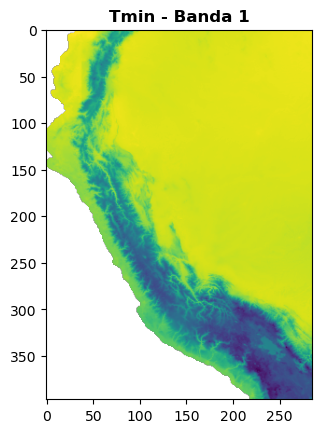

Procesando banda 2...


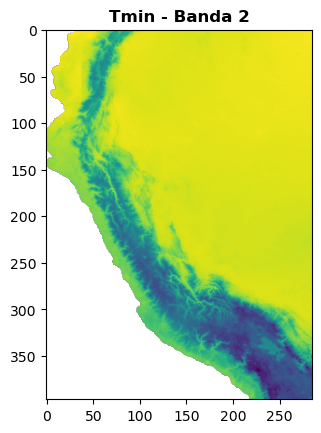

Procesando banda 3...


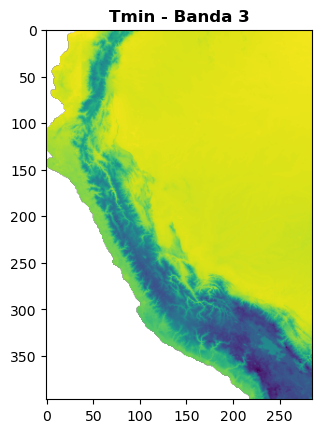

Procesando banda 4...


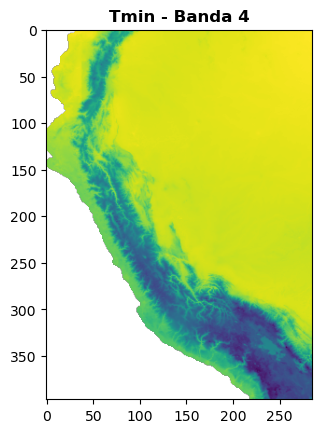

Procesando banda 5...


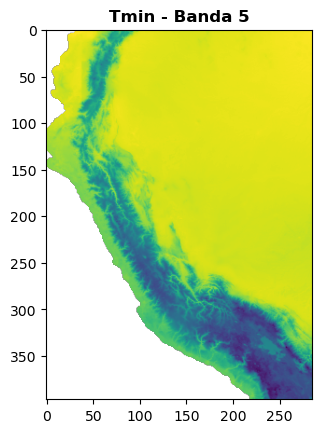

In [8]:
# El raster tiene varias bandas (por meses o años), entonces las recorremos
for i in range(1, raster.count + 1):
    band_data = raster.read(i)
    print(f"Procesando banda {i}...")
    show(band_data, title=f"Tmin - Banda {i}")

In [9]:
# Voy a validar que geometrías son válidas
print(boundaries.is_valid.value_counts())
boundaries = boundaries[boundaries.is_valid]


True    1874
Name: count, dtype: int64


In [10]:
# También, voy a ver que coincida
print("CRS límites:", boundaries.crs)
print("CRS raster:", raster.crs)


CRS límites: EPSG:4326
CRS raster: EPSG:4326


In [11]:
#Ahora revisamos extensión espacial (bounds) 
print("\n🗺️ Extensión del shapefile:", boundaries.total_bounds)
print("🗺️ Extensión del raster:", raster.bounds)

# Se comprueba si se superponen
from shapely.geometry import box

bbox_vector = box(*boundaries.total_bounds)
bbox_raster = box(*raster.bounds)

if bbox_vector.intersects(bbox_raster):
    print("El shapefile y el raster se superponen correctamente")
else:
    print("No se superponen: revisa si están en zonas distintas o CRS distintos.")

# Se revisa resolución del raster 
print("\n📏 Resolución del raster (tamaño de píxel):", raster.res)

# Todos los resultados muestran que todo está alineado entre el shapefile distrital y el raster


🗺️ Extensión del shapefile: [-8.13282305e+01 -1.83509277e+01 -6.86522791e+01 -3.86059690e-02]
🗺️ Extensión del raster: BoundingBox(left=-81.38, bottom=-18.65000000000002, right=-67.1300000000008, top=1.2000000000000002)
El shapefile y el raster se superponen correctamente

📏 Resolución del raster (tamaño de píxel): (0.04999999999999716, 0.050000000000000044)


## Zonal stats

In [13]:
# Zonal stats (at least: mean, min, max, std, p10, p90) + one custom metric.
boundaries = gpd.read_file(shp_path)
raster = rasterio.open(raster_path)


if boundaries.crs != raster.crs:
    boundaries = boundaries.to_crs(raster.crs)

print(f"✓ Datos cargados: {len(boundaries)} distritos")


stats = zonal_stats(boundaries, raster_path, 
                    stats=['mean', 'min', 'max', 'std', 'median'],
                    percentile=[10, 90],
                    add_stats={'rango': lambda x: np.max(x) - np.min(x)})

df = pd.DataFrame(stats)

# Verificar columnas generadas y renombrar
print(f"Columnas generadas: {list(df.columns)}")

# Renombrar solo las columnas que existen
if 'mean' in df.columns:
    df = df.rename(columns={
        'mean': 'Temp_Media',
        'min': 'Temp_Min', 
        'max': 'Temp_Max',
        'std': 'Temp_Desv',
        'median': 'Temp_Mediana',
        'percentile_10': 'P10',
        'percentile_90': 'P90',
        'rango': 'Rango'
    })

# Agregar columnas de ubicación
df.insert(0, 'DISTRITO', boundaries['NOMBDIST'].values)
df.insert(1, 'PROVINCIA', boundaries['NOMBPROV'].values)
df.insert(2, 'DEPARTAMENTO', boundaries['NOMBDEP'].values)

gdf = gpd.GeoDataFrame(df, geometry=boundaries.geometry, crs=boundaries.crs)

print(f"✓ Estadísticas calculadas\n{df[['Temp_Media', 'Temp_Min', 'Temp_Max']].describe()}")

✓ Datos cargados: 1874 distritos
Columnas generadas: ['min', 'max', 'mean', 'std', 'median', 'rango']
✓ Estadísticas calculadas
        Temp_Media     Temp_Min     Temp_Max
count  1790.000000  1790.000000  1790.000000
mean      9.645885     7.406829    11.861696
std       7.004712     7.331077     6.685677
min      -5.241692    -8.782926    -3.204630
25%       4.009272     1.836247     6.128598
50%       8.569635     5.450457    11.617040
75%      15.450253    12.712108    17.793315
max      23.294387    22.989103    23.911810


In [14]:
df.to_csv('estadisticas_completas_2.csv', index=False, encoding='utf-8-sig') 
df.nsmallest(20, 'Temp_Media').to_csv('top20_mas_frios_2.csv', 
index=False, encoding='utf-8-sig') 
print("✓ CSVs exportados")

✓ CSVs exportados


✓ Gráfico 1 guardado


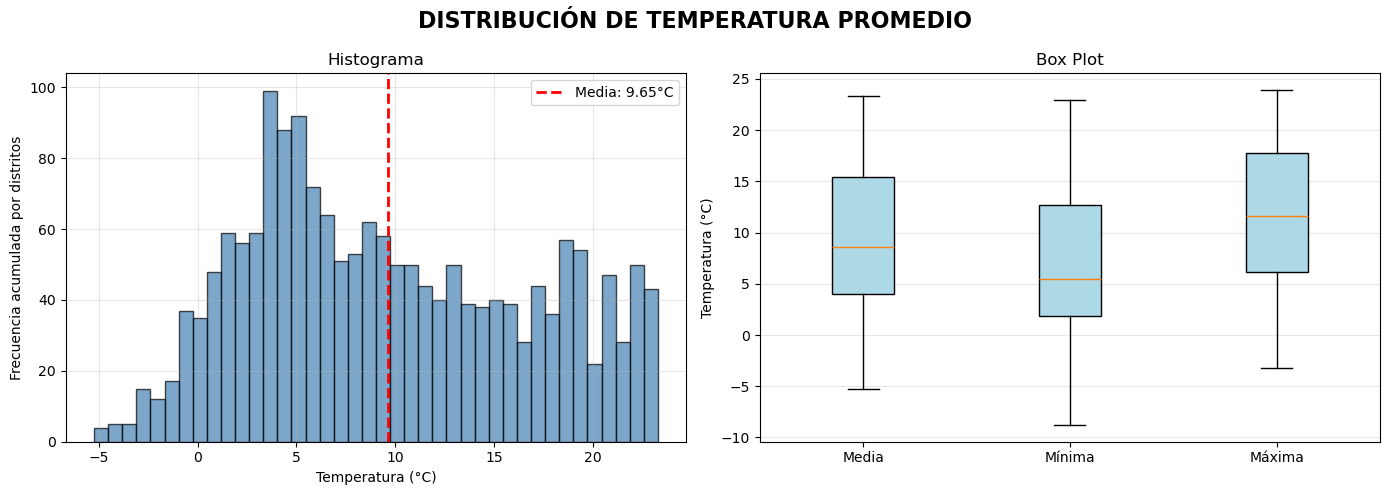

In [15]:
# At least 3 plots: distribution, ranking, and a static map.
# ========== GRÁFICO 1: DISTRIBUCIÓN ==========
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('DISTRIBUCIÓN DE TEMPERATURA PROMEDIO', fontsize=16, fontweight='bold')

# Limpiar datos para el histograma
temp_media_limpia = df['Temp_Media'].dropna()
axes[0].hist(temp_media_limpia, bins=40, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].axvline(temp_media_limpia.mean(), color='red', linestyle='--', linewidth=2, 
                label=f"Media: {temp_media_limpia.mean():.2f}°C")
axes[0].set_xlabel('Temperatura (°C)')
axes[0].set_ylabel('Frecuencia acumulada por distritos')
axes[0].set_title('Histograma')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Limpiar datos para boxplot (eliminar NaN)
datos_box = [df['Temp_Media'].dropna(), 
             df['Temp_Min'].dropna(), 
             df['Temp_Max'].dropna()]
bp = axes[1].boxplot(datos_box, 
                     labels=['Media', 'Mínima', 'Máxima'],
                     patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
axes[1].set_ylabel('Temperatura (°C)')
axes[1].set_title('Box Plot')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('01_distribucion_v2.png', dpi=300, bbox_inches='tight')
print("✓ Gráfico 1 guardado")
plt.show()


✓ Gráfico 1b guardado


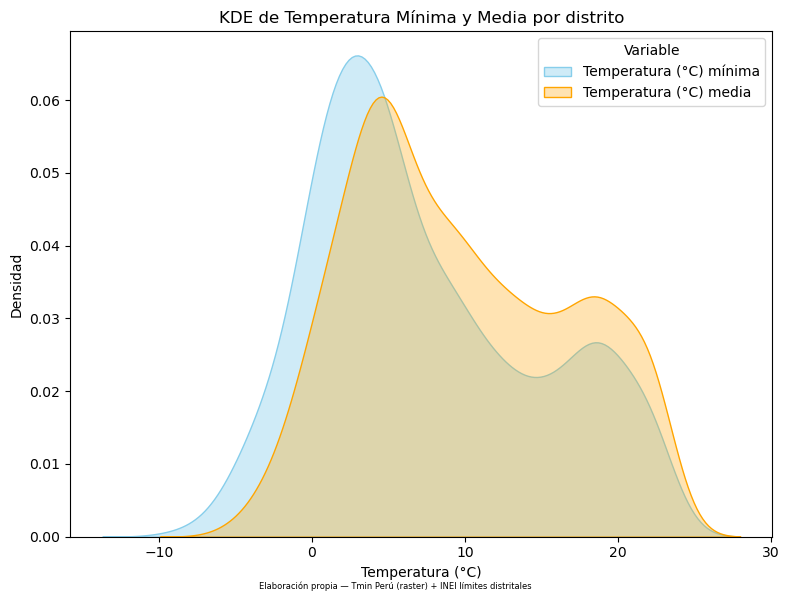

In [16]:
# ========== GRÁFICO 1B: KDE de Temperatura Mínima y Temperatura media ==========
plt.figure(figsize=(8,6))

# KDE de Temperatura mínima
sns.kdeplot(df['Temp_Min'].dropna(),   fill=True, alpha=0.4, color='skyblue', label='Temperatura (°C) mínima')

# KDE de Temperatura media
sns.kdeplot(df['Temp_Media'].dropna(), fill=True, alpha=0.3, color='orange',    label='Temperatura (°C) media')

plt.title('KDE de Temperatura Mínima y Media por distrito')
plt.xlabel('Temperatura (°C)')
plt.ylabel('Densidad')
plt.legend(title='Variable')

txt = "Elaboración propia — Tmin Perú (raster) + INEI límites distritales"
plt.figtext(0.5, 0.01, txt, wrap=True, horizontalalignment='center', fontsize=6)

plt.tight_layout()
plt.savefig('01b_distribucion.png', dpi=300, bbox_inches='tight')
print("✓ Gráfico 1b guardado")
plt.show()


In [ ]:
#El gráfico muestra dos distribuciones: la temperatura mínima y la temperatura mínima media. La curva azul está desplazada a la izquierda de la naranja, lo que indica que los episodios de frío son más intensos que el nivel habitual, por lo que podría tratarse de picos de heladas de temperaturas que están por debajo del 0°C.

✓ Gráfico 2 guardado


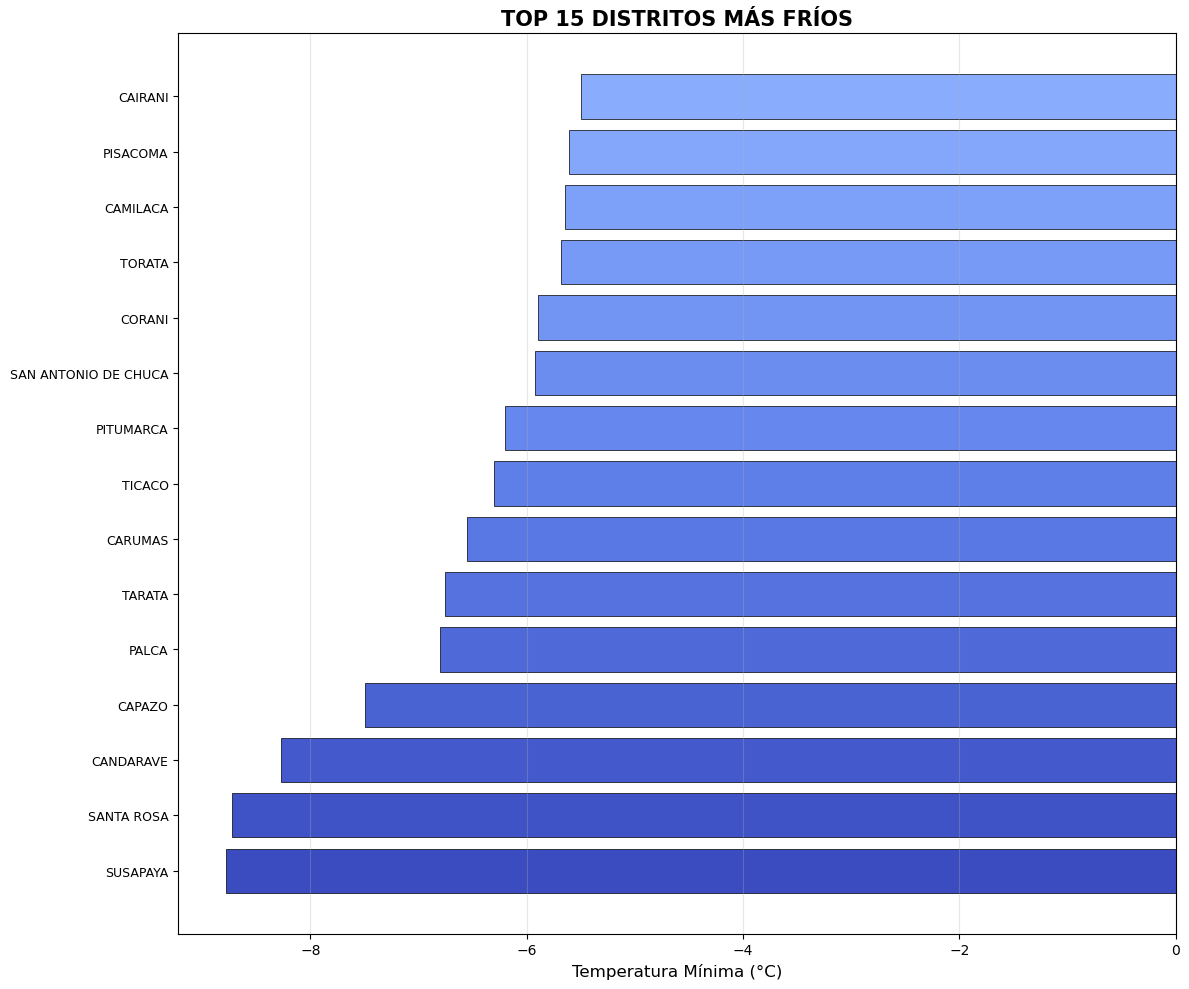

In [56]:
# ========== GRÁFICO 2: RANKING ==========
fig, ax = plt.subplots(figsize=(12, 10))
top15 = df.nsmallest(15, 'Temp_Min').sort_values('Temp_Min')

colors = plt.cm.coolwarm(np.linspace(0, 0.5, len(top30)))
ax.barh(range(len(top15)), top15['Temp_Min'], color=colors, edgecolor='black', linewidth=0.5)
ax.set_yticks(range(len(top15)))
ax.set_yticklabels([f"{row['DISTRITO']}" for _, row in top15.iterrows()], fontsize=9)
ax.set_xlabel('Temperatura Mínima (°C)', fontsize=12)
ax.set_title('TOP 15 DISTRITOS MÁS FRÍOS', fontsize=15, fontweight='bold')
ax.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('02_ranking_v2.png', dpi=300, bbox_inches='tight')
print("✓ Gráfico 2 guardado")
plt.show()

✓ Gráfico 2c guardado


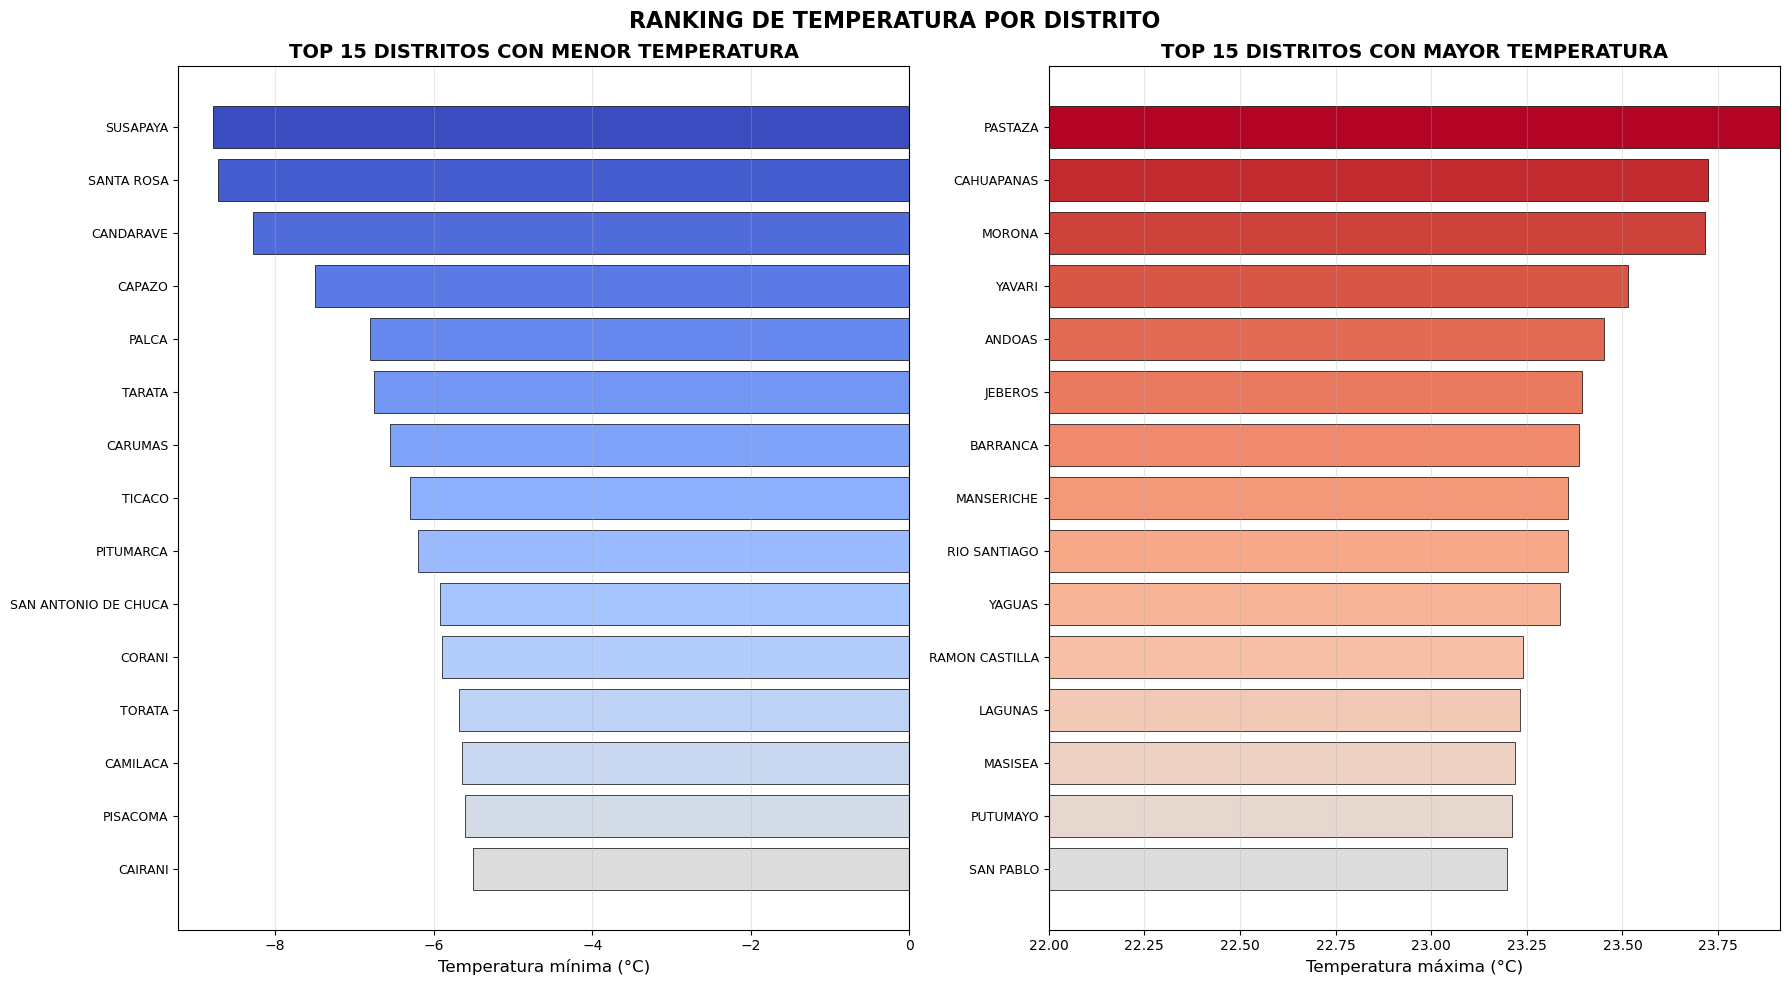

In [24]:
cold = df.nsmallest(15, 'Temp_Min').sort_values ('Temp_Min', ascending = True)
hot = df.nlargest(15, 'Temp_Max').sort_values('Temp_Max', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 10))
fig.suptitle('RANKING DE TEMPERATURA POR DISTRITO', fontsize=16, fontweight='bold')

# ------------------ Panel izquierdo: TOP 15 MÁS FRÍOS ------------------
ax = axes[0]
colors_cold = plt.cm.coolwarm(np.linspace(0.0, 0.5, len(cold)))  # gama fría
ax.barh(range(len(cold)), cold['Temp_Min'], color=colors_cold, edgecolor='black', linewidth=0.5)
ax.set_yticks(range(len(cold)))
ax.set_yticklabels([f"{row['DISTRITO']}" for _, row in cold.iterrows()], fontsize=9)
ax.set_xlabel('Temperatura mínima (°C)', fontsize=12)
ax.set_title('TOP 15 DISTRITOS CON MENOR TEMPERATURA', fontsize=14, fontweight='bold')
ax.grid(alpha=0.3, axis='x')
ax.invert_yaxis()  # más frío arriba

# ------------------ Panel derecho: TOP 15 MÁS CÁLIDOS (en temperaturas mínimas) ------------------
ax = axes[1]
colors_hot = plt.cm.coolwarm(np.linspace(0.5, 1.0, len(hot)))   # gama cálida
ax.barh(range(len(hot)), hot['Temp_Max'], color=colors_hot, edgecolor='black', linewidth=0.5)
ax.set_yticks(range(len(hot)))
ax.set_yticklabels([f"{row['DISTRITO']}" for _, row in hot.iterrows()], fontsize=9)
ax.set_xlabel('Temperatura máxima (°C)', fontsize=12)
ax.set_title('TOP 15 DISTRITOS CON MAYOR TEMPERATURA', fontsize=14, fontweight='bold')
ax.grid(alpha=0.3, axis='x')
ax.set_xlim(22, hot['Temp_Max'].max())

plt.tight_layout()
plt.savefig('02b_ranking_V3.png', dpi=300, bbox_inches='tight')
print("✓ Gráfico 2c guardado")

In [25]:

cold.to_csv('top15_mas_frios_v2.csv', index=False, encoding='utf-8-sig')
hot.to_csv('top15_mas_calurosos_v2.csv', index= False, encoding='utf-8-sig')

print("✓ CSVs exportados")


✓ CSVs exportados


✓ Gráfico 3 guardado


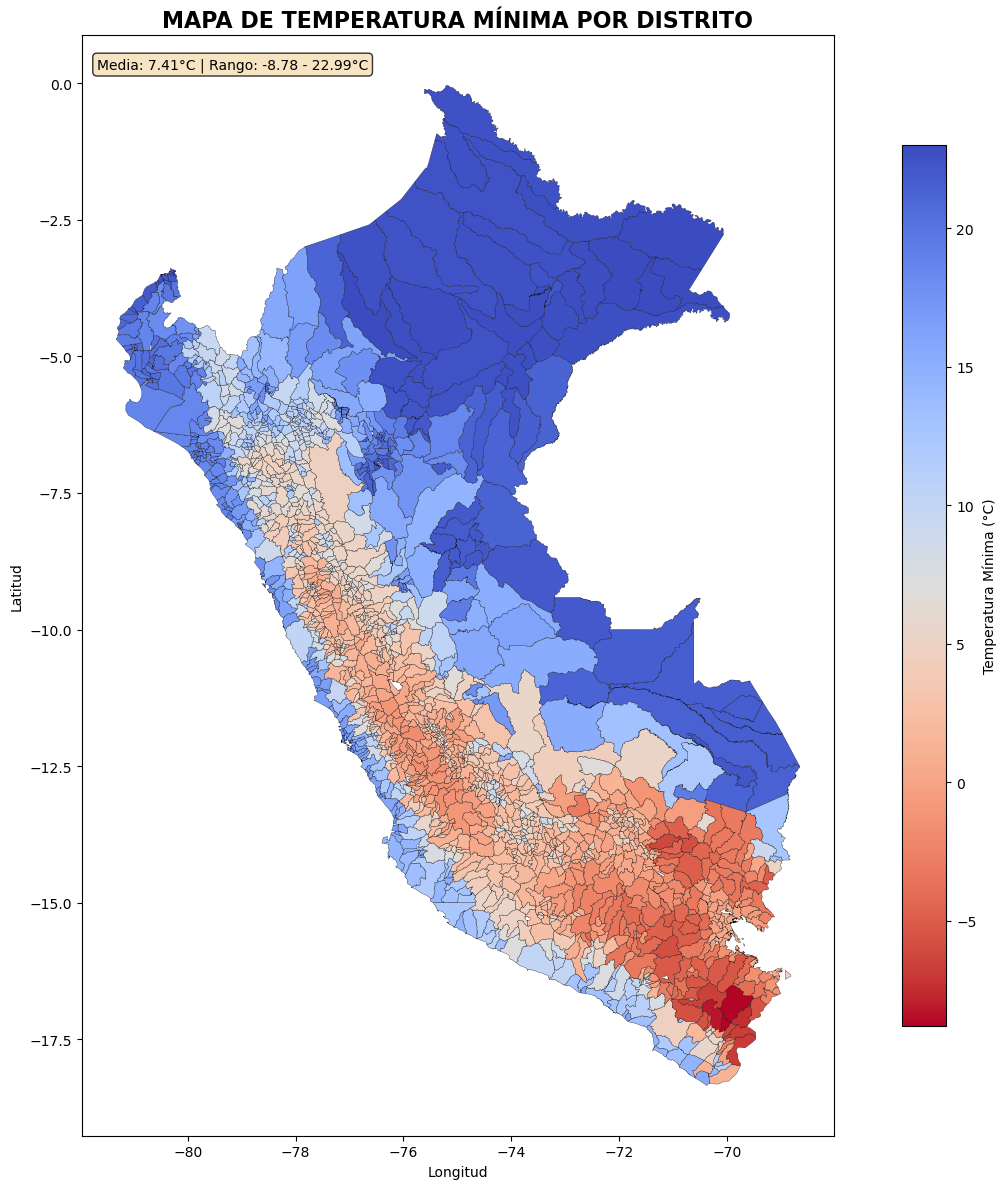

In [27]:
# ========== GRÁFICO 3: MAPA ==========
fig, ax = plt.subplots(figsize=(14, 12))
gdf.plot(column='Temp_Min', cmap='coolwarm_r', legend=True, ax=ax,
         edgecolor='black', linewidth=0.2,
         legend_kwds={'label': "Temperatura Mínima (°C)", 'shrink': 0.8})
ax.set_title('MAPA DE TEMPERATURA MÍNIMA POR DISTRITO', fontsize=16, fontweight='bold')
ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')

textstr = f'Media: {df["Temp_Min"].mean():.2f}°C | Rango: {df["Temp_Min"].min():.2f} - {df["Temp_Min"].max():.2f}°C'
ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.savefig('03_mapa_v2.png', dpi=300, bbox_inches='tight')
print("✓ Gráfico 3 guardado")
plt.show()

In [28]:
gdf.to_csv('mapa_v2.csv', index= False, encoding='utf-8-sig')

print("✓ CSV exportado")

✓ CSV exportado


## Política Pública

#### Diagnóstico
Distritos con menores temperaturas anual, con riesgo al congelamiento o friaje extremo.

In [61]:
import pandas as pd

# Calcular el valor del percentil 10 de la temperatura promedio
p10 = df['Temp_Media'].quantile(0.10)

# Calcular temperatura mínima y máxima absolutas de distritos:
min_tmin = distritos_frios['Temp_Min'].min()
max_tmax = distritos_frios['Temp_Max'].max()

# Filtrar los distritos con temperatura promedio menor o igual al percentil 10
distritos_frios = df[df['Temp_Media'] <= p10].copy()

# Seleccionar las columnas principales (ajústalas según los nombres reales en tu base)
columnas = ['DISTRITO', 'PROVINCIA', 'DEPARTAMENTO', 'Temp_Min', 'Temp_Media', 'Temp_Max']

# Crear la tabla final ordenada de más fría a menos fría
tabla_p10 = distritos_frios[columnas].sort_values('Temp_Min', ascending=True)

# Mostrar las primeras filas
print(f"Percentil 10 tiene una temperatura promedio de {p10:.2f} °C")
print(f"Temp. mínima absoluta en distritos p10: {min_tmin:.2f} °C")
print(f"Temp. máxima absoluta en distritos p10: {max_tmax:.2f} °C")

print("Número de distritos en Percentil 10 de la temperatura promedio:", len(tabla_p10))
tabla_p10.head(15)

Percentil 10 tiene una temperatura promedio de 1.21 °C
Temp. mínima absoluta en distritos p10: -8.78 °C
Temp. máxima absoluta en distritos p10: 12.96 °C
Número de distritos en Percentil 10 de la temperatura promedio: 179


,DISTRITO,PROVINCIA,DEPARTAMENTO,Temp_Min,Temp_Media,Temp_Max
1751,SUSAPAYA,TARATA,TACNA,-8.782926,-5.057250,2.722631
185,SANTA ROSA,EL COLLAO,PUNO,-8.722504,-4.926244,-2.467181
1574,CANDARAVE,CANDARAVE,TACNA,-8.273415,-4.202588,6.974405
182,CAPAZO,EL COLLAO,PUNO,-7.490873,-5.241692,-3.204630
1570,PALCA,TACNA,TACNA,-6.804277,-2.182932,9.781514
1746,TARATA,TARATA,TACNA,-6.755064,-4.893150,5.429613
1549,CARUMAS,MARISCAL NIETO,MOQUEGUA,-6.549748,-3.287404,12.256598
1580,TICACO,TARATA,TACNA,-6.302865,-4.309868,2.176187
883,PITUMARCA,CANCHIS,CUSCO,-6.198120,-2.881023,1.730878
175,SAN ANTONIO DE CHUCA,CAYLLOMA,AREQUIPA,-5.922765,-4.249321,-2.714177


El ranking de temperatura muestra que los distritos más fríos del país se concentran en la sierra sur y centro, principalmente en Puno, Arequipa, Cusco Moquegua y Tacna. En total son 179 distritos que tienen una temperatura promedio anual de 1.21 °C, con una temperatura máxima de hasta 13 °C.

In [62]:
#Conteo de distritos en el top 10 por departamento
tabla_p10['DEPARTAMENTO'].value_counts()

DEPARTAMENTO
PUNO            76
AREQUIPA        26
CUSCO           22
LIMA            14
HUANCAVELICA    11
JUNIN           11
TACNA            8
MOQUEGUA         7
APURIMAC         3
AYACUCHO         1
Name: count, dtype: int64

De la siguiente tabla se observa que el 42 % de los distritos con temperatura promedio menor o igual al percentil 10 se concentran en el departamento de Puno, seguido de Arequipa (1 %) y Cusco (12 %).

Se puede profundizar en el diagnóstico y evaluar cuales son esos distritos con temperaturas bajas extremas a lo largo de todo el año, para determinar cuáles distritos deberían ser priorizados para el establecimiento de políticas públicas.

In [66]:
# Filtrar distritos cuya temperatura promedio no supera los 0 °C
distritos_frio_extremo = df[df['Temp_Media'] <= 0].copy()

# Seleccionar las columnas principales para revisar
columnas = ['DISTRITO', 'PROVINCIA', 'DEPARTAMENTO', 'Temp_Min', 'Temp_Media', 'Temp_Max']

# Promedio de temperaturas entre distritos con Temp_Prom ≤ 0°C
promedio_min = distritos_frio_extremo['Temp_Min'].mean()
promedio_max = distritos_frio_extremo['Temp_Max'].mean()

# Crear la tabla ordenada por temperatura máxima (de menor a mayor)
tabla_frio_extremo = distritos_frio_extremo[columnas].sort_values('Temp_Min', ascending=True)

# Mostrar promedio de temperatura entre distritos de frío extremo
print(f"Promedio Temp. mínima: {promedio_min:.2f} °C")
print(f"Promedio Temp. máxima: {promedio_max:.2f} °C")

# Número total de distritos con Temp_Max ≤ 0°C
print("Número de distritos con temperatura máxima ≤ 0°C:", len(tabla_frio_extremo))
tabla_frio_extremo.head(15)

Promedio Temp. mínima: -3.56 °C
Promedio Temp. máxima: 1.56 °C
Número de distritos con temperatura máxima ≤ 0°C: 105


,DISTRITO,PROVINCIA,DEPARTAMENTO,Temp_Min,Temp_Media,Temp_Max
1751,SUSAPAYA,TARATA,TACNA,-8.782926,-5.057250,2.722631
185,SANTA ROSA,EL COLLAO,PUNO,-8.722504,-4.926244,-2.467181
1574,CANDARAVE,CANDARAVE,TACNA,-8.273415,-4.202588,6.974405
182,CAPAZO,EL COLLAO,PUNO,-7.490873,-5.241692,-3.204630
1570,PALCA,TACNA,TACNA,-6.804277,-2.182932,9.781514
1746,TARATA,TARATA,TACNA,-6.755064,-4.893150,5.429613
1549,CARUMAS,MARISCAL NIETO,MOQUEGUA,-6.549748,-3.287404,12.256598
1580,TICACO,TARATA,TACNA,-6.302865,-4.309868,2.176187
883,PITUMARCA,CANCHIS,CUSCO,-6.198120,-2.881023,1.730878
175,SAN ANTONIO DE CHUCA,CAYLLOMA,AREQUIPA,-5.922765,-4.249321,-2.714177


In [67]:
#Conteo de distritos con clima frío extremo por departamento
tabla_frio_extremo['DEPARTAMENTO'].value_counts()

DEPARTAMENTO
PUNO            48
AREQUIPA        21
CUSCO           13
TACNA            7
MOQUEGUA         5
HUANCAVELICA     5
JUNIN            4
LIMA             2
Name: count, dtype: int64

✓ Mapa de distritos de frío extremo


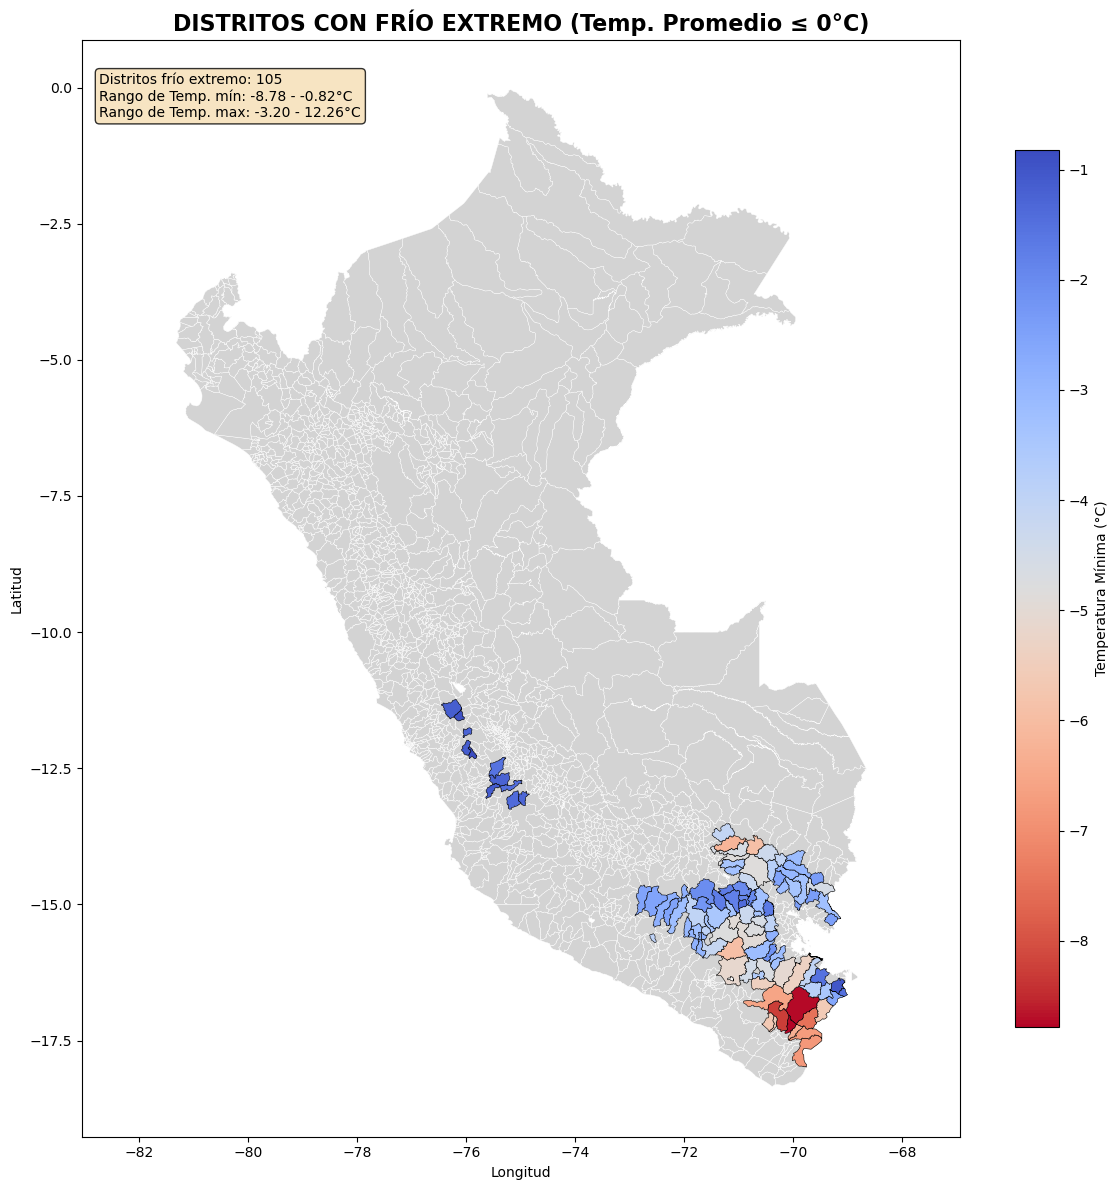

In [72]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects

# Filtrar distritos de frío extremo
gdf_frio_extremo = gdf[gdf['Temp_Media'] <= 0].copy()

# Crear mapa base
fig, ax = plt.subplots(figsize=(12, 12))
gdf.plot(ax=ax, color='lightgrey', edgecolor='white', linewidth=0.3)

# Crear el mapa SOLO con distritos de frío extremo
gdf_frio_extremo.plot(
    column='Temp_Min',
    cmap='coolwarm_r',
    legend=True,
    ax=ax,
    edgecolor='black',
    linewidth=0.4,
    legend_kwds={'label': "Temperatura Mínima (°C)", 'shrink': 0.8}
)

# Personalizar el gráfico
ax.set_title('DISTRITOS CON FRÍO EXTREMO (Temp. Promedio ≤ 0°C)', fontsize=16, fontweight='bold')
ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')

# Texto informativo
textstr = (f'Distritos frío extremo: {len(gdf_frio_extremo)}\n'
           f'Rango de Temp. mín: {gdf_frio_extremo["Temp_Min"].min():.2f} - {gdf_frio_extremo["Temp_Min"].max():.2f}°C\n'
           f'Rango de Temp. max: {gdf_frio_extremo["Temp_Max"].min():.2f} - {gdf_frio_extremo["Temp_Max"].max():.2f}°C')

ax.text(0.02, 0.97, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.axis('equal')
plt.tight_layout()
plt.savefig('04_mapa_frio_extremo.png', dpi=300, bbox_inches='tight')
print("✓ Mapa de distritos de frío extremo")
plt.show()

Solo 105 distritos del país presentan una temperatura promedio menor o igual a 0 °C, concentrándose mayoritariamente en la región altiplánica de Puno y la sierra sur (Arequipa, Cusco y Tacna). Estas zonas tienen temperaturas mínimas que están entre los -9 °C y los -1 °C en temporada de friaje, lo que representa un riesgo para su salud, la agricultura familiar y la asistencia escolar.En otras palabras, son estos 105 distritos los que constituyen territorios de alta prioridad para intervenciones de adaptación térmica y protección de la salud.

A continuación, se muestran algunos riesgos que pueden presentarse en comunidades que habitan en zonas en temperaturas bajas extremas:
1. Riesgo en la salud: aumento de infecciones respiratorias agudas (IRA) e influenza, sobre todo en niños y adultos mayores.
2. Riesgo en la agricultura y ganadería: pérdidas en cultivos de papa, cebada y quinua; alta mortalidad de alpacas y ovinos.
3. Riesgo en la educación: ausentismo escolar por bajas temperaturas y falta de infraestructura térmica.

#### Propuestas de políticas públicas
Considerando el diagnóstico de distritos con menor temperatura promedio, se proponen las siguientes 3 intervenciones enfocadas en las localidades de la sierra sur y antiplánica del país.

##### Política 1

**Programa de Viviendas Térmicas Rurales (ISUR Ampliado)**

*Objetivo:*
Reducir en un 30 % los casos de infecciones respiratorias agudas (IRA) en población infantil en zonas altoandinas con temperaturas promedio menor a 0 °C.

*Territorio y población objetivo:*
Distritos rurales en Puno, Arequipa, Cusco, Tacna, Moquegua y Huancavelica identificados como los más fríos (temperatura anual promedio por debajo de los 0 grados).
Población meta: 50 000 hogares rurales en altitudes 

*Intervención:*
1. Implementación de viviendas térmicamente mejoradas (paredes aislantes, techos dobles, sistemas pasivos de calefacción solar).
2. Complementario al programa “Mi Abrigo” (FONCODES), pero con criterios geoespaciales basados en análisis raster.

*Costo estimado:*
S/ 8 000 por vivienda con una meta de 50 000 hogares.  El costo total de la intervención asciende a S/ 400 millones.

*KPI:*

1. Disminucion en un 30 % de casos IRA en la población infantil en temporada de friaje (Fuente: ESSALUD/MINSA).
2. Aumento de un 20 % de confort térmico reportado por hogares (Fuente: SISFOH).
3. Aumento de un 15 % de asistencia escolar en invierno (Fuente: MINEDU).

##### Política 2

**Fondo de Adaptación Agropecuaria al Friaje**

*Objetivo:*
Reducir pérdidas agrícolas y ganaderas en 25 % en distritos de la sierra sur expuestos a heladas recurrentes.

*Territorio y población objetivo:*
Distritos agrícolas en Puno, Cusco y Arequipa con temperatura promedio menor a ≤ 0 °C (105 distritos).
Población meta: 30 000 productores agropecuarios familiares.

*Intervención:*
1. Entrega de kits antiheladas (módulos de riego nocturno, mantas térmicas agrícolas).
2. Capacitación en calendarios agrícolas adaptativos.
3. Construcción de módulos de refugio ganadero para alpacas y ovinos.

*Costo estimado:*
S/ 8 000 por agricultor con una meta de 30 000 trabajadores. El costo total de la intervención asciende a S/ 240 millones.

*KPI:*

1. Disminuación en un 25 % de pérdidas reportadas en cultivos andinos (Fuente: MINAGRI).
2. Disminución en un 15 % de mortalidad de alpacas y ovinos en época de heladas(Fuente: SENASA).
3. 80% de agricultores capacitados adoptan prácticas agrícolas adaptadas al clima (Fuente: MINAGRI).

##### Política 3

**Escuelas Seguras ante Friaje**

*Objetivo:*
Reducir el ausentismo escolar por eventos de friaje en un 40 % en zonas altoandinas con temperaturas promedio menor a 0 °C.

*Territorio y población objetivo:*
Distritos rurales en Puno, Arequipa, Cusco, Tacna, Moquegua y Huancavelica identificados como los más fríos (temperatura anual promedio por debajo de los 0 grados). Población meta: 20 000 estudiantes y 250 escuelas rurales.

*Intervención:*
1. Implementación de protocolos escolares de abrigo y refugio.
2. Entrega de kits de calefacción solar y ropa térmica a escolares.
3. Implementación de escuelas térmicamente mejoradas. Instalar paredes aislantes, techos dobles, sistemas pasivos de calefacción solar en entre 1 a 3 espacios de las escuelas rurales (dependiendo del tamaño de la población escolar).

*Costo estimado:*
S/ 30 000 por escuela con una meta 250 escuelas beneficiadas. El costo total de la intervención asciende a S/ 7,5 millones.

*KPI:*
1. Reducción de un 40 % de ausentismo escolar en temporada de friaje (Fuente: MINEDU).
2. 100% de escuelas beneficiadas aumentan la temperatura de salones en +5 °C durante temporada de friaje (Fuente: MINEDU).